In [1]:
# Import
import os
import matplotlib.pyplot as plt
import seaborn as sns
import io
import splitfolders

In [ ]:
# downloading dataset manually

In [8]:
!echo %cd%

C:\Users\ArifMammadov\Documents\COAE\Jupyter Notebooks


In [11]:
!dir ..\Datasets

 Volume in drive C has no label.
 Volume Serial Number is EAB1-CBD0

 Directory of C:\Users\ArifMammadov\Documents\COAE\Datasets

05/20/2026  12:40 PM    <DIR>          .
05/20/2026  12:38 PM    <DIR>          ..
05/13/2026  02:54 PM    <DIR>          anomaly_detection_collection
05/12/2026  02:00 AM             3,267 demo_dataset.csv
05/19/2026  04:41 PM    <DIR>          malimg_paper_dataset_imgs
05/19/2026  04:56 PM    <DIR>          newdata
05/12/2026  02:33 PM    <DIR>          sms_spam_collection
               1 File(s)          3,267 bytes
               6 Dir(s)  638,370,791,424 bytes free


In [15]:
DATA_BASE_PATH = '../Datasets/malimg_paper_dataset_imgs/'
TARGET_BASE_PATH = '../Datasets/newdata/'

In [33]:
dist = {}
for mlw_class in os.listdir(DATA_BASE_PATH):
    mlw_dir = os.path.join(DATA_BASE_PATH, mlw_class)
    dist[mlw_class] = len(os.listdir(mlw_dir))

for k,v in enumerate(dist):
    print(f"{v}:\t\t {dist[v]} images")

Adialer.C:		 122 images
Agent.FYI:		 116 images
Allaple.A:		 2949 images
Allaple.L:		 1591 images
Alueron.gen!J:		 198 images
Autorun.K:		 106 images
C2LOP.gen!g:		 200 images
C2LOP.P:		 146 images
Dialplatform.B:		 177 images
Dontovo.A:		 162 images
Fakerean:		 381 images
Instantaccess:		 431 images
Lolyda.AA1:		 213 images
Lolyda.AA2:		 184 images
Lolyda.AA3:		 123 images
Lolyda.AT:		 159 images
Malex.gen!J:		 136 images
Obfuscator.AD:		 142 images
Rbot!gen:		 158 images
Skintrim.N:		 80 images
Swizzor.gen!E:		 128 images
Swizzor.gen!I:		 132 images
VB.AT:		 408 images
Wintrim.BX:		 97 images
Yuner.A:		 800 images


In [16]:
# Don't run | Already split
TRAINING_RATIO = 0.8
TEST_RATIO = 1 - TRAINING_RATIO

# ratio=(train, val, test) — val=0 since we skip validation
splitfolders.ratio(
    input=DATA_BASE_PATH,
    output=TARGET_BASE_PATH,
    ratio=(TRAINING_RATIO, 0, TEST_RATIO)
)

print('Dataset split complete!')

Dataset split complete!


In [36]:
# Verify Split
def count_files(folder):
    total = 0
    for root, dirs, files in os.walk(folder):
        total += len(files)
    return total

train_count = count_files('../Datasets/newdata/train/')
test_count  = count_files('../Datasets/newdata/test/')
val_count   = count_files('../Datasets/newdata/val/')

print(f'Training images:   {train_count}')
print(f'Test images:       {test_count}')
print(f'Validation images: {val_count}')
print(f'Total:             {train_count + test_count + val_count}')

Training images:   7462
Test images:       1884
Validation images: 0
Total:             9346


In [35]:
# Preprocessing
from torchvision import transforms

# Preprocessing pipeline:
# 1. Resize all images to 75x75
# 2. Convert to PyTorch tensor
# 3. Normalize using ImageNet mean/std
transform = transforms.Compose([
    transforms.Resize((75, 75)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print('Transforms defined:')
print(transform)

# If you use `pretrained weights`, you should almost always use ImageNet normalization because:
#  the model expects that input distribution
#  activations behave correctly
#  convergence is better

Transforms defined:
Compose(
    Resize(size=(75, 75), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [37]:
#Loading datasets
from torchvision.datasets import ImageFolder

BASE_PATH = '../Datasets/newdata/'

# ImageFolder reads class labels from folder names automatically
train_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, 'train'),
    transform=transform
)

test_dataset = ImageFolder(
    root=os.path.join(BASE_PATH, 'test'),
    transform=transform
)

n_classes = len(train_dataset.classes)

print(f'Number of classes: {n_classes}')
print(f'Classes: {train_dataset.classes}')
print(f'Training samples: {len(train_dataset)}')
print(f'Test samples:     {len(test_dataset)}')

Number of classes: 25
Classes: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A', 'Fakerean', 'Instantaccess', 'Lolyda.AA1', 'Lolyda.AA2', 'Lolyda.AA3', 'Lolyda.AT', 'Malex.gen!J', 'Obfuscator.AD', 'Rbot!gen', 'Skintrim.N', 'Swizzor.gen!E', 'Swizzor.gen!I', 'VB.AT', 'Wintrim.BX', 'Yuner.A']
Training samples: 7462
Test samples:     1884


In [38]:
# Creating Dataloaders
from torch.utils.data import DataLoader

TRAIN_BATCH_SIZE = 1024
TEST_BATCH_SIZE  = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,       # shuffle every epoch during training
    num_workers=2       # parallel loading
)

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,      # no shuffle for test set
    num_workers=2
)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 8
Test batches:  2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.2456646].


Image tensor shape: torch.Size([3, 75, 75])
Label: Allaple.A


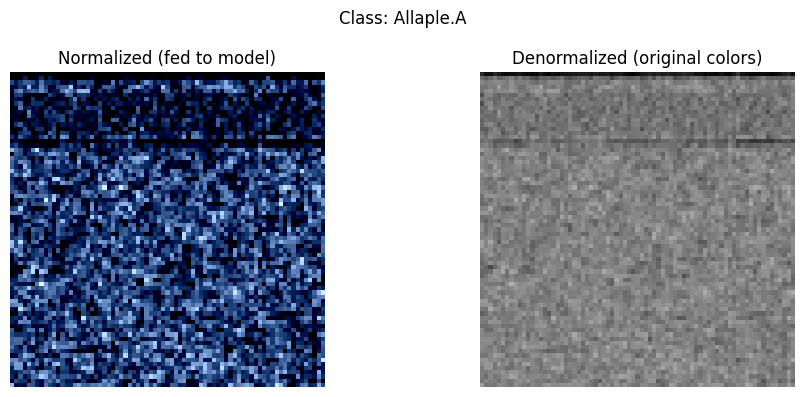

In [40]:
# Sample Image Visualization
# Get one batch, take first image
sample_batch = next(iter(train_loader))
sample_image = sample_batch[0][30]   # first image in batch
sample_label = sample_batch[1][30]   # its label

print(f'Image tensor shape: {sample_image.shape}')   # [3, 75, 75]
print(f'Label: {train_dataset.classes[sample_label]}')

# Denormalize for visualization
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

img = sample_image.clone()
for i in range(3):
    img[i] = img[i] * std[i] + mean[i]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Raw tensor (normalized)
axes[0].imshow(sample_image.permute(1, 2, 0))
axes[0].set_title('Normalized (fed to model)')
axes[0].axis('off')

# Denormalized
axes[1].imshow(img.permute(1, 2, 0).clamp(0, 1))
axes[1].set_title('Denormalized (original colors)')
axes[1].axis('off')

plt.suptitle(f'Class: {train_dataset.classes[sample_label]}')
plt.tight_layout()
plt.show()

In [12]:
print("Salam 1")

Salam 1


In [13]:
import torch.nn as nn
import torchvision.models as models

HIDDEN_LAYER_SIZE = 1000

class MalwareClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MalwareClassifier, self).__init__()
        # Load pretrained ResNet50
        self.resnet = models.resnet50(weights='DEFAULT')
        
        # Freeze ResNet parameters
        for param in self.resnet.parameters():
            param.requires_grad = False
        
        # Replace the last fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(num_features, HIDDEN_LAYER_SIZE),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_SIZE, n_classes)
        )

    def forward(self, x):
        return self.resnet(x)

# Initialize model
n_classes = len(train_dataset.classes)
print(f"n_classes: {n_classes}")
model = MalwareClassifier(n_classes)

n_classes: 25
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ArifMammadov/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


In [14]:
# Training
import torch
import time

def train(model, train_loader, n_epochs, verbose=False):
    model.train()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())

    training_data = {"accuracy": [], "loss": []}
    
    for epoch in range(n_epochs):
        running_loss = 0
        n_total = 0
        n_correct = 0
        checkpoint = time.time() * 1000
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            n_total += labels.size(0)
            n_correct += predicted.eq(labels).sum().item()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        epoch_duration = int(time.time() * 1000 - checkpoint)
        epoch_accuracy = compute_accuracy(n_correct, n_total)
        
        training_data["accuracy"].append(epoch_accuracy)
        training_data["loss"].append(epoch_loss)
        
        if verbose:
            print(f"[i] Epoch {epoch+1} of {n_epochs}: Acc: {epoch_accuracy:.2f}% Loss: {epoch_loss:.4f} (Took {epoch_duration} ms).")    
    
    return training_data

In [15]:
# Saving the model
def save_model(model, path):
    model_scripted = torch.jit.script(model)
    model_scripted.save(path)

In [17]:
def predict(model, test_data):
    model.eval()

    with torch.no_grad():
        output = model(test_data)
        _, predicted = torch.max(output.data, 1)

    return predicted

def compute_accuracy(n_correct, n_total):
    return round(100 * n_correct / n_total, 2)


def evaluate(model, test_loader):
    model.eval()

    n_correct = 0
    n_total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            predicted = predict(model, data)
            n_total += target.size(0)
            n_correct += (predicted == target).sum().item()

    accuracy = compute_accuracy(n_correct, n_total)  

    return accuracy

In [18]:
# training parameters
N_EPOCHS = 10
TRAINING_BATCH_SIZE = 512
TEST_BATCH_SIZE = 1024

# model parameters
HIDDEN_LAYER_SIZE = 1000
MODEL_FILE = "malware_classifier.pth"

In [19]:
# Train model
print("[i] Starting Training...")  
training_information = train(model, train_loader, N_EPOCHS, verbose=True)

# Save model
save_model(model, MODEL_FILE)

# evaluate model
accuracy = evaluate(model, test_loader)
print(f"[i] Inference accuracy: {accuracy}%.")

[i] Starting Training...
[i] Epoch 1 of 10: Acc: 45.62% Loss: 1.8999 (Took 39442 ms).
[i] Epoch 2 of 10: Acc: 78.92% Loss: 0.7454 (Took 36664 ms).
[i] Epoch 3 of 10: Acc: 87.63% Loss: 0.4059 (Took 34817 ms).
[i] Epoch 4 of 10: Acc: 90.59% Loss: 0.2842 (Took 35236 ms).
[i] Epoch 5 of 10: Acc: 92.13% Loss: 0.2335 (Took 35938 ms).
[i] Epoch 6 of 10: Acc: 93.06% Loss: 0.2024 (Took 35686 ms).
[i] Epoch 7 of 10: Acc: 93.71% Loss: 0.1870 (Took 36170 ms).
[i] Epoch 8 of 10: Acc: 94.93% Loss: 0.1561 (Took 34449 ms).
[i] Epoch 9 of 10: Acc: 95.46% Loss: 0.1410 (Took 34898 ms).
[i] Epoch 10 of 10: Acc: 96.27% Loss: 0.1280 (Took 38691 ms).
[i] Inference accuracy: 88.11%.
